# Laboratorio #1 — Entrenamiento de Redes Neuronales (MLP)
## CC3092 · Deep Learning y Sistemas Inteligentes

**Problema:** Regresión sobre el dataset *California Housing Prices*. El objetivo es predecir el valor mediano de una vivienda (`median_house_value`) a partir de características socioeconómicas y geográficas de distritos censales de California, usando un **Perceptrón Multicapa (MLP)** implementado en **PyTorch**.

**Repositorio:** _(colocar aquí el enlace al repositorio Git antes de la entrega)_

---

### Contenido del notebook
0. Configuración del entorno
1. Carga y exploración de los datos (§2)
2. Preparación de los datos: limpieza, codificación, escalado y *split* (§2)
3. Investigación: capas de `torch.nn` y optimizadores (§3)
4. Definición del modelo MLP y funciones de entrenamiento/evaluación (§4)
5. Entrenamiento e iteración de hiperparámetros — 10+ configuraciones (§4)
6. Selección del mejor modelo y evaluación única sobre *test* (§4)
7. Tabla resumen de iteraciones (§5)

## 0. Configuración del entorno

Importamos las librerías y fijamos una **semilla** para que los resultados sean reproducibles (mismo *split*, misma inicialización de pesos y mismo orden de *batches* en cada corrida). También detectamos el *device* disponible (CPU / GPU).

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- Reproducibilidad ---
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch: {torch.__version__}")
print(f"Device : {device}")
print(f"Semilla: {SEED}")

PyTorch: 2.13.0
Device : cpu
Semilla: 42


---
## 1. Carga y exploración de los datos

Usamos la versión de **Kaggle** (`data/housing.csv`), que a diferencia de la de `sklearn` incluye la variable **categórica** `ocean_proximity` y filas con **valores nulos**, lo que nos permite demostrar codificación de categóricas y manejo de nulos.

In [2]:
# Carga del dataset
DATA_PATH = "../data/housing.csv"
df = pd.read_csv(DATA_PATH)

print(f"Observaciones (filas): {df.shape[0]:,}")
print(f"Variables (columnas) : {df.shape[1]}")
df.head()

Observaciones (filas): 20,640
Variables (columnas) : 10


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Tipos de dato e información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
# Estadísticos descriptivos de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [5]:
# Valores nulos y duplicados
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")

# Variable categórica
print("\nNiveles de 'ocean_proximity':")
print(df["ocean_proximity"].value_counts())

Valores nulos por columna:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Filas duplicadas: 0

Niveles de 'ocean_proximity':
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


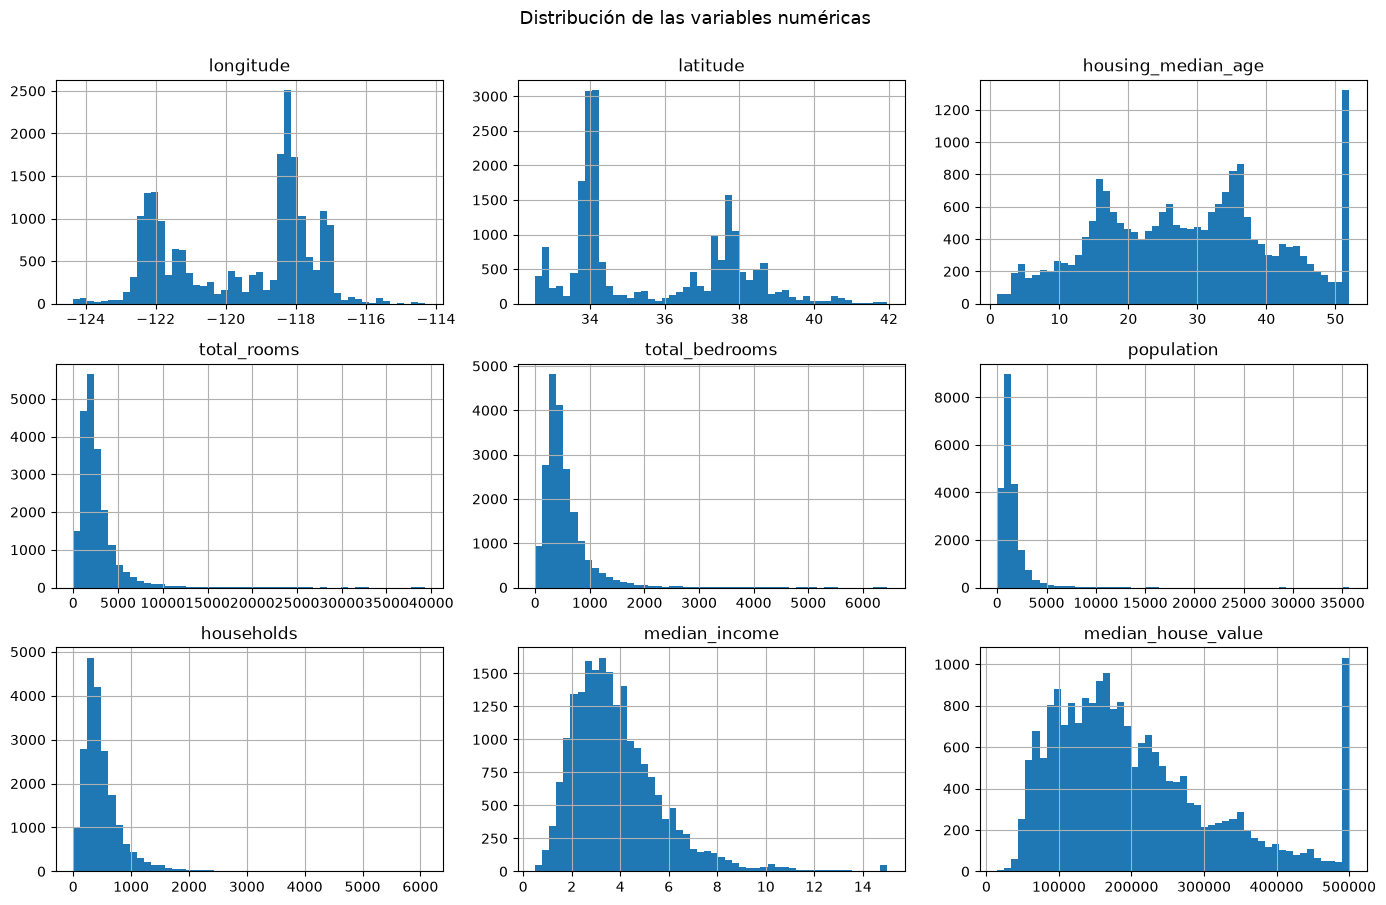

In [6]:
# Distribución de todas las variables numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].hist(bins=50, figsize=(14, 9))
plt.suptitle("Distribución de las variables numéricas", y=1.0, fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# Diagnóstico de censura (capping) en el target y en algunas features
cap_target = (df["median_house_value"] >= 500_001).sum()
cap_income = (df["median_income"] >= 15.0001).sum()
cap_age = (df["housing_median_age"] >= 52).sum()
print(f"median_house_value censurado en 500,001 : {cap_target:,} filas ({cap_target/len(df):.1%})")
print(f"median_income tope en 15.0001            : {cap_income:,} filas")
print(f"housing_median_age tope en 52            : {cap_age:,} filas")

# Asimetría (skew) de las features numéricas: valores altos => cola larga / outliers
skew = df[num_cols].drop(columns=["median_house_value"]).skew().sort_values(ascending=False)
print("\nAsimetría (skew) de las features numéricas:")
print(skew.round(2))

median_house_value censurado en 500,001 : 965 filas (4.7%)
median_income tope en 15.0001            : 49 filas
housing_median_age tope en 52            : 1,273 filas

Asimetría (skew) de las features numéricas:
population            4.94
total_rooms           4.15
total_bedrooms        3.46
households            3.41
median_income         1.65
latitude              0.47
housing_median_age    0.06
longitude            -0.30
dtype: float64


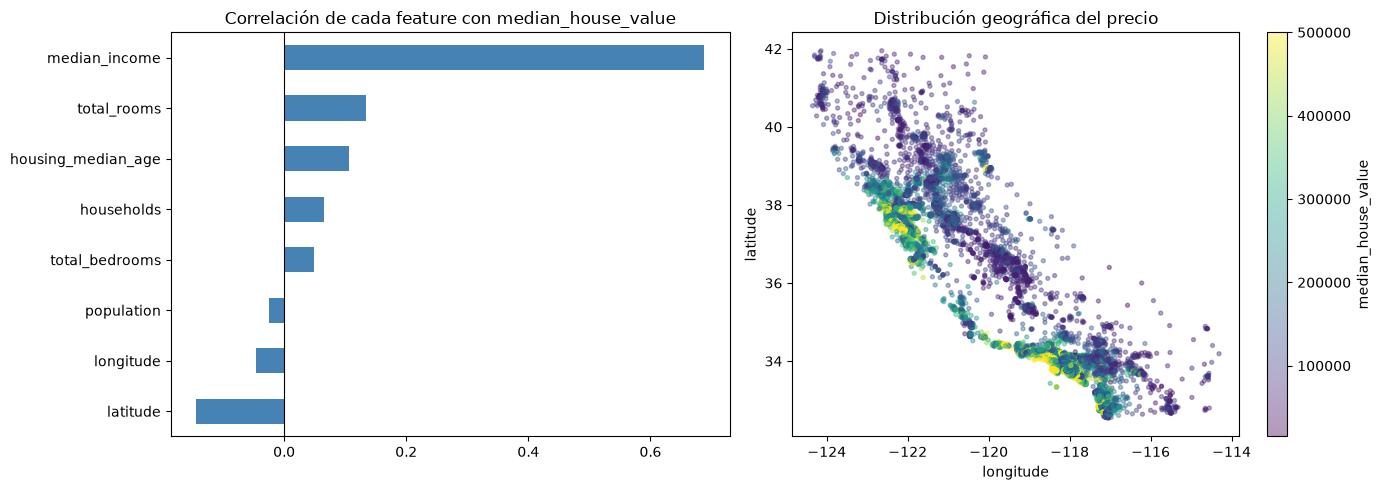

In [8]:
# Correlación de las variables numéricas con el target
corr = df[num_cols].corr()["median_house_value"].drop("median_house_value").sort_values()
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

corr.plot(kind="barh", ax=ax[0], color="steelblue")
ax[0].set_title("Correlación de cada feature con median_house_value")
ax[0].axvline(0, color="k", lw=0.8)

sc = ax[1].scatter(df["longitude"], df["latitude"], c=df["median_house_value"],
                   cmap="viridis", s=8, alpha=0.4)
ax[1].set_title("Distribución geográfica del precio")
ax[1].set_xlabel("longitude"); ax[1].set_ylabel("latitude")
plt.colorbar(sc, ax=ax[1], label="median_house_value")
plt.tight_layout()
plt.show()

### Respuestas a las preguntas de exploración (P2)

**a) ¿Cuántas observaciones y cuántas variables tiene el dataset?**
El dataset tiene **20,640 observaciones** (distritos censales) y **10 variables**: 9 *features* y 1 variable objetivo.

**b) ¿Qué representa cada variable y cuál es el *target*?**

| Variable | Tipo | Descripción |
|---|---|---|
| `longitude`, `latitude` | numérica | Coordenadas geográficas del distrito. |
| `housing_median_age` | numérica | Antigüedad mediana de las viviendas (años). |
| `total_rooms` | numérica | Nº total de habitaciones en el distrito. |
| `total_bedrooms` | numérica | Nº total de dormitorios en el distrito. |
| `population` | numérica | Población del distrito. |
| `households` | numérica | Nº de hogares del distrito. |
| `median_income` | numérica | Ingreso mediano de los hogares (en decenas de miles de USD). |
| `ocean_proximity` | **categórica** | Cercanía al océano (`<1H OCEAN`, `INLAND`, `NEAR OCEAN`, `NEAR BAY`, `ISLAND`). |
| **`median_house_value`** | numérica | **TARGET**: valor mediano de la vivienda (USD). |

El EDA muestra que `median_income` es la feature con **mayor correlación positiva** con el precio (~0.69), y geográficamente los precios altos se concentran en la costa (Bahía de San Francisco y Los Ángeles).

**c) ¿Hay valores nulos, duplicados o atípicos (outliers)? ¿Cómo los trató?**
- **Nulos:** sí, solo en `total_bedrooms` → **207 filas** (~1% del dataset). *Estrategia:* imputar con la **mediana** calculada **únicamente en el conjunto de entrenamiento** (para no filtrar información de validación/test). Se hace en el Bloque 2.
- **Duplicados:** **0 filas** duplicadas, no se elimina nada.
- **Outliers / censura:** las features de conteo (`total_rooms`, `population`, `households`, `total_bedrooms`) están muy **sesgadas a la derecha** (skew de 3.4 a 4.9), con colas largas. Además hay **censura (capping)**: el target está topado en `500,001` (**965 filas ≈ 4.7%**), `median_income` en `15.0001` (49 filas) y `housing_median_age` en `52` (1,273 filas). *Estrategia:* **no se eliminan** los outliers (son datos reales y quitarlos sesgaría el modelo); en su lugar se controla su efecto con el **escalado estandarizado** (Bloque 2). Se documenta la censura del target porque limita el error mínimo alcanzable en ese rango.

**d) ¿Qué variables son numéricas y cuáles categóricas? ¿Cómo codificó las categóricas?**
- **Numéricas (8 features):** todas menos `ocean_proximity`.
- **Categórica (1):** `ocean_proximity`. Se codifica con **One-Hot Encoding** (`pd.get_dummies`), generando una columna binaria por nivel. Es nominal (sin orden), por lo que One-Hot es más apropiado que un *label encoding* ordinal. Con 5 niveles el aumento de dimensionalidad es mínimo.

**e) ¿Fue necesario normalizar o escalar las variables numéricas?**
**Sí, es imprescindible.** Las features están en escalas radicalmente distintas (`median_income` ∈ [0.5, 15] frente a `total_rooms` ∈ [2, 39,320]). Sin escalar, las features de mayor magnitud dominarían el gradiente y el entrenamiento del MLP sería inestable y lento. Se aplica **estandarización** (`StandardScaler`: media 0, desviación 1), **ajustada solo con el train** y aplicada a val/test.

---
## 2. Preparación de los datos

Regla clave (vista en clase): **el conjunto de *test* no debe influir en ninguna decisión**. Por eso el orden es:

1. **Primero** dividimos en `train` / `val` / `test` (**70 / 15 / 15**). Con 20,640 filas, val y test quedan con ~3,100 ejemplos cada uno — suficientes para una estimación estable de las métricas — mientras el train se lleva la mayor parte de los datos, siguiendo la guía de clase (train 70-80%, val/test 10-15%).
2. Todo lo que "aprende" de los datos (mediana para imputar, columnas del *one-hot*, media y desviación del escalado) se **ajusta únicamente con el `train`** y luego se **aplica** a `val` y `test`.

Además, estandarizamos también el **target**: los valores están en cientos de miles de USD, y estandarizarlos (media 0, desv. 1) estabiliza el entrenamiento. Guardamos el `scaler_y` para **invertir** las predicciones y reportar las métricas (MSE, MAE, RMSE) en **dólares reales**.

In [9]:
# --- 1) Separar features (X) y target (y) ---
target_col = "median_house_value"
X = df.drop(columns=[target_col]).copy()
y = df[[target_col]].copy()

cat_cols = ["ocean_proximity"]
num_cols_feat = [c for c in X.columns if c not in cat_cols]

# --- 2) Split 70/15/15 (primero test 15%, luego val del 85% restante) ---
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15 / 0.85, random_state=SEED)  # 0.1765 * 0.85 = 0.15

for name, part in [("train", X_train), ("val", X_val), ("test", X_test)]:
    print(f"{name:5s}: {part.shape[0]:>6,} filas  ({part.shape[0]/len(X):.0%})")

train: 14,448 filas  (70%)
val  :  3,096 filas  (15%)
test :  3,096 filas  (15%)


In [10]:
# --- 3) Imputación de nulos: mediana calculada SOLO con el train ---
X_train, X_val, X_test = X_train.copy(), X_val.copy(), X_test.copy()

median_bedrooms = X_train["total_bedrooms"].median()
X_train["total_bedrooms"] = X_train["total_bedrooms"].fillna(median_bedrooms)
X_val["total_bedrooms"]   = X_val["total_bedrooms"].fillna(median_bedrooms)
X_test["total_bedrooms"]  = X_test["total_bedrooms"].fillna(median_bedrooms)

print(f"Mediana de total_bedrooms (train): {median_bedrooms:.1f}")
print("Nulos restantes tras imputar:",
      int(pd.concat([X_train, X_val, X_test])["total_bedrooms"].isnull().sum()))

# --- 4) One-Hot Encoding de la categórica (columnas del train como referencia) ---
X_train = pd.get_dummies(X_train, columns=cat_cols)
X_val   = pd.get_dummies(X_val,   columns=cat_cols)
X_test  = pd.get_dummies(X_test,  columns=cat_cols)

# Alinear val/test a las columnas del train (mismo conjunto y orden de dummies)
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("\nColumnas finales tras one-hot:")
print(list(X_train.columns))

Mediana de total_bedrooms (train): 435.0
Nulos restantes tras imputar: 0

Columnas finales tras one-hot:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


In [11]:
# --- 5) Escalado estandarizado (StandardScaler) ajustado SOLO con el train ---
# Solo escalamos las columnas numéricas; las dummies (0/1) se dejan intactas.
scaler_x = StandardScaler()
X_train[num_cols_feat] = scaler_x.fit_transform(X_train[num_cols_feat])
X_val[num_cols_feat]   = scaler_x.transform(X_val[num_cols_feat])
X_test[num_cols_feat]  = scaler_x.transform(X_test[num_cols_feat])

# Estandarizamos también el target (se invertirá para reportar métricas en USD)
scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

print("Media/desv del target (train):",
      f"mean={scaler_y.mean_[0]:,.0f}  std={scaler_y.scale_[0]:,.0f}")
print("Features numéricas escaladas (media≈0, std≈1):")
print(X_train[num_cols_feat].describe().loc[["mean", "std"]].T.round(2))

Media/desv del target (train): mean=206,296  std=115,519
Features numéricas escaladas (media≈0, std≈1):


                    mean  std
longitude            0.0  1.0
latitude            -0.0  1.0
housing_median_age   0.0  1.0
total_rooms         -0.0  1.0
total_bedrooms      -0.0  1.0
population          -0.0  1.0
households          -0.0  1.0
median_income       -0.0  1.0


In [12]:
# --- 6) Conversión a tensores de PyTorch ---
def to_tensor(arr):
    return torch.tensor(np.asarray(arr, dtype=np.float32))

X_train_t = to_tensor(X_train.astype(np.float32).values)
X_val_t   = to_tensor(X_val.astype(np.float32).values)
X_test_t  = to_tensor(X_test.astype(np.float32).values)
y_train_t = to_tensor(y_train_s)
y_val_t   = to_tensor(y_val_s)
y_test_t  = to_tensor(y_test_s)

n_features = X_train_t.shape[1]

# Datasets (los DataLoaders se crean por iteración, ya que batch_size es un hiperparámetro)
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t,   y_val_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

print(f"n_features de entrada: {n_features}")
print(f"X_train: {tuple(X_train_t.shape)} | X_val: {tuple(X_val_t.shape)} | X_test: {tuple(X_test_t.shape)}")
print(f"y_train: {tuple(y_train_t.shape)} | y_val: {tuple(y_val_t.shape)} | y_test: {tuple(y_test_t.shape)}")

n_features de entrada: 13
X_train: (14448, 13) | X_val: (3096, 13) | X_test: (3096, 13)
y_train: (14448, 1) | y_val: (3096, 1) | y_test: (3096, 1)


---
## 3. Investigación: capas de `torch.nn` y optimizadores

### 3.1 Capas para construir el MLP

| Capa | Propósito | Parámetros clave |
|---|---|---|
| **`nn.Linear`** | Capa densa: aplica `y = xWᵀ + b`. Es el bloque base del MLP; conecta todas las entradas con todas las neuronas de salida. | `in_features`, `out_features`, `bias` (usar sesgo, por defecto `True`). |
| **`nn.ReLU`** | Activación no lineal `max(0, x)`. Barata y sin saturación en positivos → converge rápido. Su riesgo son las *dying neurons* (neuronas que quedan en 0). | *(sin parámetros relevantes)* |
| **`nn.LeakyReLU`** | Variante de ReLU con pendiente pequeña para negativos (`x` si `x>0`, `αx` si `x≤0`). Evita las neuronas muertas. | `negative_slope` (α, típ. 0.01). |
| **`nn.Tanh`** | Activación `tanh(x)` con salida en (−1, 1), centrada en 0. Satura en los extremos → puede causar gradientes que se desvanecen en redes profundas. | *(sin parámetros relevantes)* |
| **`nn.Dropout`** | Regularización: durante el entrenamiento apaga aleatoriamente una fracción de neuronas, forzando redundancia y reduciendo *overfitting*. Se desactiva en evaluación. | `p` = probabilidad de apagado (0.2–0.5 típico). |
| **`nn.BatchNorm1d`** | Normaliza las activaciones de cada *batch* (media 0, var 1) y las reescala con parámetros aprendibles. Estabiliza y acelera el entrenamiento, permite `lr` mayores y aporta ligera regularización. | `num_features` (= nº de neuronas de la capa previa). |

### 3.2 Funciones de pérdida para regresión

| Pérdida | Fórmula (por muestra) | Comportamiento |
|---|---|---|
| **`nn.MSELoss`** | `(ŷ − y)²` | Penaliza fuerte los errores grandes (cuadrático) → muy **sensible a outliers**. Es la más usada en regresión; su raíz es el RMSE. |
| **`nn.L1Loss`** (MAE) | `|ŷ − y|` | Penalización lineal → **robusta a outliers**. Trata todos los errores por igual; su gradiente es constante. |
| **`nn.SmoothL1Loss`** (Huber) | cuadrática si `|error| < β`, lineal si es mayor | **Híbrido**: precisa como MSE cerca del cero y robusta como L1 en los errores grandes. Parámetro `beta` marca el umbral de cambio. |

### 3.3 Optimizadores (`torch.optim`)

Dos parámetros comunes a los tres:
- **`lr` (learning rate):** tamaño del paso al actualizar los pesos. **Muy alto** → el entrenamiento diverge u oscila; **muy bajo** → converge lento o se estanca. Es el hiperparámetro más crítico.
- **`weight_decay` (regularización L2):** penaliza pesos grandes sumando `λ·‖w‖²` a la pérdida. Reduce el *overfitting* al mantener los pesos pequeños.

| Optimizador | Cómo actualiza | Qué lo diferencia |
|---|---|---|
| **`SGD`** | Paso en dirección del gradiente, igual para todos los pesos. Suele usarse con `momentum` (acumula inercia). | El más simple y predecible, pero **sensible al `lr`** y lento sin *momentum*. Con buen ajuste puede generalizar muy bien. |
| **`Adam`** | `lr` **adaptativo por parámetro**, combinando momento de 1er orden (media del gradiente) y de 2º (varianza). | **Convergencia rápida y robusta** con poco ajuste. Suele ser la opción por defecto en MLPs. |
| **`RMSprop`** | Divide el `lr` por la media móvil de los gradientes al cuadrado (adapta por parámetro, sin el momento de 1er orden de Adam). | Bueno con objetivos **no estacionarios/ruidosos**; es, en esencia, Adam sin el término de momento. |

**Función en el entrenamiento del MLP:** el optimizador es quien traduce los gradientes calculados por *backpropagation* en actualizaciones concretas de los pesos. La elección afecta directamente la **velocidad de convergencia** y la **estabilidad**: los adaptativos (Adam, RMSprop) suelen converger antes con menos ajuste, mientras que SGD requiere más cuidado con el `lr` pero puede lograr mejor generalización. En las iteraciones del Bloque 5 comparamos los tres.

---
## 4. Modelo MLP y funciones de entrenamiento / evaluación

Definimos una clase `MLP` **configurable** para poder variar en cada iteración (Bloque 5) la arquitectura, la activación, el *dropout* y el uso de *BatchNorm* **sin reescribir código**. La salida es una única neurona **sin activación** (regresión: no queremos acotar el rango del precio).

También definimos:
- `train_model(config, ...)` → entrena por epochs con mini-batches, registra la pérdida de **train y val por epoch**, y soporta regularización **L2** (`weight_decay`), **L1** (penalización manual) y **dropout**.
- `evaluate(model, ...)` → calcula **MSE, MAE y RMSE en dólares reales**, invirtiendo el escalado del target con `scaler_y`.

In [13]:
class MLP(nn.Module):
    """MLP de regresión configurable.

    hidden_layers : lista con el nº de neuronas de cada capa oculta, p.ej. [64, 32].
    activation    : 'relu' | 'leaky_relu' | 'tanh'.
    dropout       : probabilidad de dropout (0 = sin dropout).
    batchnorm     : si True, añade BatchNorm1d después de cada capa lineal oculta.
    """
    def __init__(self, n_features, hidden_layers, activation="relu",
                 dropout=0.0, batchnorm=False):
        super().__init__()
        act_map = {"relu": nn.ReLU, "leaky_relu": nn.LeakyReLU, "tanh": nn.Tanh}
        Act = act_map[activation]

        layers, in_dim = [], n_features
        for h in hidden_layers:
            layers.append(nn.Linear(in_dim, h))
            if batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(Act())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))   # salida de regresión (sin activación)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Prueba rápida de construcción
demo = MLP(n_features, hidden_layers=[64, 32], activation="relu", dropout=0.2, batchnorm=True)
print(demo)

MLP(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [14]:
def build_optimizer(model, config):
    """Crea el optimizador según la config. weight_decay = regularización L2."""
    name = config.get("optimizer", "adam")
    lr = config.get("lr", 1e-3)
    wd = config.get("weight_decay", 0.0)
    if name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr,
                               momentum=config.get("momentum", 0.9), weight_decay=wd)
    if name == "rmsprop":
        return torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=wd)
    return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)


def train_model(config, train_ds, val_ds, n_features, verbose=False):
    """Entrena un MLP según `config` y devuelve (modelo, history).

    history = {'train_loss': [...], 'val_loss': [...]}  (una entrada por epoch).
    La pérdida registrada es siempre la del criterio base (sin el término L1),
    para que train y val sean directamente comparables en las gráficas.
    """
    set_seed(SEED)  # misma inicialización/orden de batches en cada iteración

    model = MLP(n_features,
                hidden_layers=config["hidden_layers"],
                activation=config.get("activation", "relu"),
                dropout=config.get("dropout", 0.0),
                batchnorm=config.get("batchnorm", False)).to(device)

    loss_map = {"mse": nn.MSELoss, "l1": nn.L1Loss, "smoothl1": nn.SmoothL1Loss}
    criterion = loss_map[config.get("loss", "mse")]()
    optimizer = build_optimizer(model, config)

    l1_lambda = config.get("l1_lambda", 0.0)      # regularización L1 (manual)
    batch_size = config.get("batch_size", 64)
    epochs = config.get("epochs", 50)

    g = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g)

    Xv, yv = val_ds.tensors
    Xv, yv = Xv.to(device), yv.to(device)

    history = {"train_loss": [], "val_loss": []}
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            base_loss = criterion(pred, yb)
            loss = base_loss
            if l1_lambda > 0:
                loss = loss + l1_lambda * sum(p.abs().sum() for p in model.parameters())
            loss.backward()
            optimizer.step()
            running += base_loss.item() * xb.size(0)   # solo criterio base
        train_loss = running / len(train_ds)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(Xv), yv).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if verbose and (epoch + 1) % max(1, epochs // 5) == 0:
            print(f"  epoch {epoch+1:3d}/{epochs}  train={train_loss:.4f}  val={val_loss:.4f}")

    return model, history

In [15]:
def evaluate(model, ds, scaler_y):
    """Devuelve MSE, MAE y RMSE en DÓLARES REALES (invierte el escalado del target)."""
    model.eval()
    X, y = ds.tensors
    with torch.no_grad():
        pred_s = model(X.to(device)).cpu().numpy()
    pred = scaler_y.inverse_transform(pred_s)      # de vuelta a USD
    true = scaler_y.inverse_transform(y.numpy())
    mse = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    rmse = float(np.sqrt(mse))
    return {"MSE": float(mse), "MAE": float(mae), "RMSE": rmse}


def plot_history(history, title=""):
    """Grafica las curvas de pérdida de train y validación."""
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.xlabel("epoch"); plt.ylabel("loss (target estandarizado)")
    plt.title(title); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

In [16]:
# Prueba de humo: entrenamiento corto para validar el pipeline completo
_smoke_cfg = {"hidden_layers": [64, 32], "activation": "relu",
              "optimizer": "adam", "lr": 1e-3, "batch_size": 64, "epochs": 5}
_m, _h = train_model(_smoke_cfg, train_ds, val_ds, n_features, verbose=True)
print("Métricas (val, USD):", {k: round(v) for k, v in evaluate(_m, val_ds, scaler_y).items()})

  epoch   1/5  train=0.4270  val=0.2984
  epoch   2/5  train=0.2923  val=0.2745
  epoch   3/5  train=0.2739  val=0.2698
  epoch   4/5  train=0.2636  val=0.2557


  epoch   5/5  train=0.2560  val=0.2501
Métricas (val, USD): {'MSE': 3337395968, 'MAE': 39839, 'RMSE': 57770}


---
## 5. Entrenamiento e iteración de hiperparámetros

Realizamos **14 iteraciones** siguiendo una **búsqueda tipo grid parcial**: partimos de un *baseline* y cambiamos **una o dos variables a la vez**, para poder **atribuir el efecto** de cada cambio. La estrategia por grupos:

| Grupo | Iteraciones | Qué se varía (respecto a la referencia) |
|---|---|---|
| Baseline | 1 | Punto de partida `[64,32]`, ReLU, Adam, lr=1e-3. |
| Arquitectura | 2, 3 | Red más profunda `[128,64,32]` vs. más pequeña `[32,16]`. |
| Activación | 4, 5 | `Tanh` y `LeakyReLU` (sobre la arquitectura profunda). |
| Optimizador | 6, 7 | `SGD` y `RMSprop` (vs. Adam). |
| Learning rate | 8, 9 | lr alto (1e-2) y lr bajo (1e-4). |
| Regularización | 10, 11, 12 | L2 (`weight_decay`), Dropout y L1 por separado. |
| Batch size | 13 | Batch grande (256) en lugar de 64. |
| Combinada | 14 | Dropout + L2 + BatchNorm + más epochs. |

De la iteración 2 en adelante, la **arquitectura de referencia** es `[128,64,32]` con ReLU/Adam/lr=1e-3/batch=64/epochs=60, de modo que cada grupo aísla el efecto de su cambio. Para cada iteración registramos la config, la curva de pérdida train/val por epoch y las métricas **MSE, MAE, RMSE sobre validación**.

In [17]:
# Referencia común para la mayoría de iteraciones: [128,64,32] ReLU Adam lr=1e-3 batch=64 epochs=60
REF = dict(hidden_layers=[128, 64, 32], activation="relu", optimizer="adam",
           lr=1e-3, batch_size=64, epochs=60, loss="mse")

def cfg(**changes):
    """Devuelve una copia de REF con los cambios indicados."""
    c = REF.copy(); c.update(changes); return c

configs = [
    # id, grupo, descripción del cambio, config
    (1,  "Baseline",     "[64,32] ReLU Adam 1e-3",       cfg(hidden_layers=[64, 32])),
    (2,  "Arquitectura", "[128,64,32] (más profunda)",   cfg()),
    (3,  "Arquitectura", "[32,16] (más pequeña)",        cfg(hidden_layers=[32, 16])),
    (4,  "Activación",   "Tanh",                         cfg(activation="tanh")),
    (5,  "Activación",   "LeakyReLU",                    cfg(activation="leaky_relu")),
    (6,  "Optimizador",  "SGD lr=1e-2 (momentum 0.9)",   cfg(optimizer="sgd", lr=1e-2)),
    (7,  "Optimizador",  "RMSprop 1e-3",                 cfg(optimizer="rmsprop")),
    (8,  "Learning rate","Adam lr=1e-2 (alto)",          cfg(lr=1e-2)),
    (9,  "Learning rate","Adam lr=1e-4 (bajo)",          cfg(lr=1e-4)),
    (10, "Regularización","L2 weight_decay=1e-4",        cfg(weight_decay=1e-4)),
    (11, "Regularización","Dropout=0.3",                 cfg(dropout=0.3)),
    (12, "Regularización","L1 lambda=1e-5",              cfg(l1_lambda=1e-5)),
    (13, "Batch size",   "batch=256",                    cfg(batch_size=256)),
    (14, "Combinada",    "Dropout0.2+L2 1e-4+BN, 100 ep",cfg(dropout=0.2, weight_decay=1e-4,
                                                            batchnorm=True, epochs=100)),
]
print(f"Total de iteraciones a entrenar: {len(configs)}")

Total de iteraciones a entrenar: 14


In [18]:
import time

def fmt_reg(c):
    """Resumen legible de la regularización usada."""
    parts = []
    if c.get("weight_decay", 0): parts.append(f"L2={c['weight_decay']:g}")
    if c.get("l1_lambda", 0):    parts.append(f"L1={c['l1_lambda']:g}")
    if c.get("dropout", 0):      parts.append(f"drop={c['dropout']}")
    if c.get("batchnorm", False):parts.append("BN")
    return "+".join(parts) if parts else "—"

runs = {}        # id -> {"model":..., "history":..., "config":...}
rows = []        # filas para la tabla resumen

t0 = time.time()
for idx, grupo, desc, c in configs:
    ti = time.time()
    model, history = train_model(c, train_ds, val_ds, n_features)
    val_metrics = evaluate(model, val_ds, scaler_y)
    runs[idx] = {"model": model, "history": history, "config": c, "grupo": grupo, "desc": desc}
    rows.append({
        "#": idx,
        "Grupo": grupo,
        "Arquitectura": str(c["hidden_layers"]),
        "Activación": c["activation"],
        "Optim/LR": f"{c['optimizer']}/{c['lr']:g}",
        "Batch/Epochs": f"{c['batch_size']}/{c['epochs']}",
        "Regularización": fmt_reg(c),
        "MSE (val)": val_metrics["MSE"],
        "MAE (val)": val_metrics["MAE"],
        "RMSE (val)": val_metrics["RMSE"],
    })
    print(f"[{idx:2d}/{len(configs)}] {grupo:13s} {desc:32s} "
          f"RMSE={val_metrics['RMSE']:>8,.0f}  ({time.time()-ti:4.1f}s)")

print(f"\nTiempo total: {time.time()-t0:.1f}s")
results = pd.DataFrame(rows)

[ 1/14] Baseline      [64,32] ReLU Adam 1e-3           RMSE=  51,868  ( 3.2s)


[ 2/14] Arquitectura  [128,64,32] (más profunda)       RMSE=  51,598  ( 4.7s)


[ 3/14] Arquitectura  [32,16] (más pequeña)            RMSE=  53,288  ( 3.0s)


[ 4/14] Activación    Tanh                             RMSE=  51,357  ( 5.8s)


[ 5/14] Activación    LeakyReLU                        RMSE=  51,373  ( 4.8s)


...

[10/14] Regularización L2 weight_decay=1e-4             RMSE=  51,901  ( 4.8s)


[11/14] Regularización Dropout=0.3                      RMSE=  52,022  ( 5.5s)


[12/14] Regularización L1 lambda=1e-5                   RMSE=  51,122  ( 5.9s)


[13/14] Batch size    batch=256                        RMSE=  51,468  ( 2.2s)


[14/14] Combinada     Dropout0.2+L2 1e-4+BN, 100 ep    RMSE=  50,965  (29.1s)

Tiempo total: 85.9s


In [19]:
# Tabla resumen, ordenada por RMSE de validación (menor = mejor)
results_sorted = results.sort_values("RMSE (val)").reset_index(drop=True)
fmt = {"MSE (val)": "{:,.0f}".format, "MAE (val)": "{:,.0f}".format, "RMSE (val)": "{:,.0f}".format}
results_sorted.style.format(fmt).background_gradient(subset=["RMSE (val)"], cmap="RdYlGn_r")

,#,Grupo,Arquitectura,Activación,Optim/LR,Batch/Epochs,Regularización,MSE (val),MAE (val),RMSE (val)
0,14,Combinada,"[128, 64, 32]",relu,adam/0.001,64/100,L2=0.0001+drop=0.2+BN,"2,597,420,288","34,503","50,965"
1,12,Regularización,"[128, 64, 32]",relu,adam/0.001,64/60,L1=1e-05,"2,613,474,304","34,513","51,122"
2,4,Activación,"[128, 64, 32]",tanh,adam/0.001,64/60,—,"2,637,513,984","34,295","51,357"
3,5,Activación,"[128, 64, 32]",leaky_relu,adam/0.001,64/60,—,"2,639,161,856","34,643","51,373"
4,7,Optimizador,"[128, 64, 32]",relu,rmsprop/0.001,64/60,—,"2,644,834,816","33,534","51,428"
5,13,Batch size,"[128, 64, 32]",relu,adam/0.001,256/60,—,"2,648,952,576","35,062","51,468"
6,2,Arquitectura,"[128, 64, 32]",relu,adam/0.001,64/60,—,"2,662,400,256","34,504","51,598"
7,1,Baseline,"[64, 32]",relu,adam/0.001,64/60,—,"2,690,290,688","34,898","51,868"
8,10,Regularización,"[128, 64, 32]",relu,adam/0.001,64/60,L2=0.0001,"2,693,670,912","35,419","51,901"
9,11,Regularización,"[128, 64, 32]",relu,adam/0.001,64/60,drop=0.3,"2,706,255,360","35,883","52,022"


In [20]:
# Diagnóstico de overfitting/underfitting: gap entre train y val al final del entrenamiento
diag = []
for idx, r in runs.items():
    h = r["history"]
    tr, va = h["train_loss"][-1], h["val_loss"][-1]
    diag.append({"#": idx, "desc": r["desc"],
                 "train_final": tr, "val_final": va,
                 "gap(val-train)": va - tr,
                 "min_val": min(h["val_loss"]),
                 "epoch_min_val": int(np.argmin(h["val_loss"])) + 1})
diag = pd.DataFrame(diag).set_index("#")
diag.round(4)

,desc,train_final,val_final,gap(val-train),min_val,epoch_min_val
#,,,,,,
1,"[64,32] ReLU Adam 1e-3",0.1824,0.2016,0.0192,0.1984,54
2,"[128,64,32] (más profunda)",0.1559,0.1995,0.0436,0.1942,52
3,"[32,16] (más pequeña)",0.1979,0.2128,0.0149,0.2114,49
4,Tanh,0.1700,0.1976,0.0276,0.1945,54
5,LeakyReLU,0.1554,0.1978,0.0424,0.1931,52
6,SGD lr=1e-2 (momentum 0.9),0.1666,0.2067,0.0401,0.1872,54
7,RMSprop 1e-3,0.1526,0.1982,0.0456,0.1925,38
8,Adam lr=1e-2 (alto),0.1731,0.2098,0.0368,0.1948,37
9,Adam lr=1e-4 (bajo),0.1992,0.2083,0.0091,0.2083,60


### Curvas de pérdida: overfitting vs. underfitting vs. buen ajuste

Graficamos 3 iteraciones representativas. Señales que buscamos:
- **Overfitting:** la pérdida de *train* sigue bajando pero la de *val* se estanca o sube → hay **gap** entre ambas (val > train).
- **Underfitting:** *ambas* pérdidas quedan altas (el modelo no tiene capacidad o no entrenó lo suficiente).
- **Buen ajuste:** *train* y *val* bajan juntas y el gap es pequeño (o val ≤ train cuando hay dropout/BN activos solo en entrenamiento).

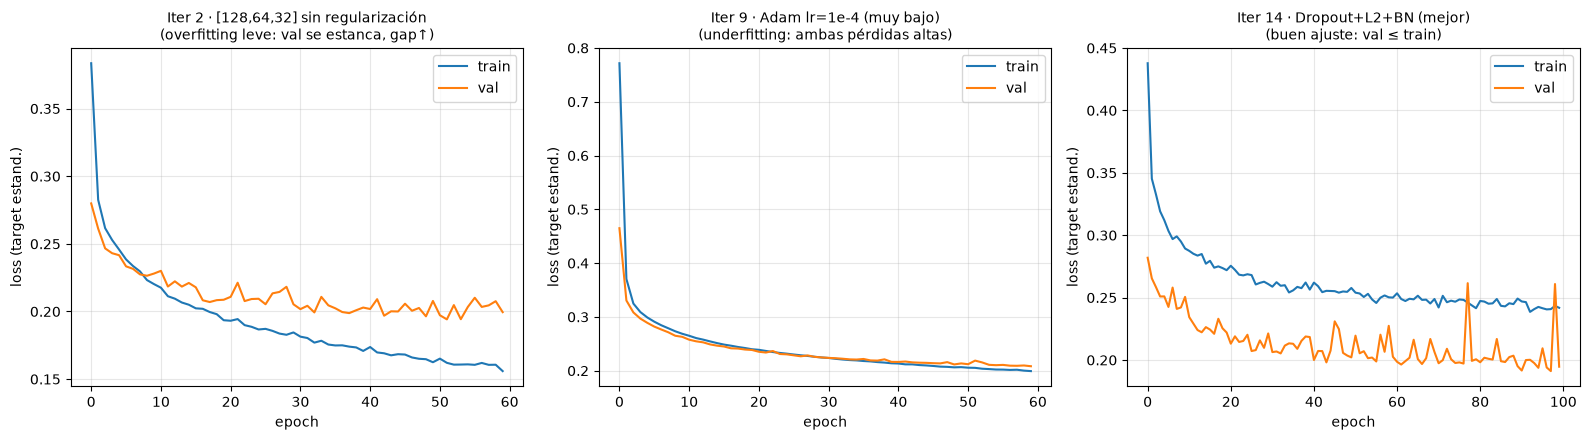

In [21]:
# Curvas de 3 iteraciones representativas
sel = [2, 9, 14]
titles = {
    2:  "Iter 2 · [128,64,32] sin regularización\n(overfitting leve: val se estanca, gap↑)",
    9:  "Iter 9 · Adam lr=1e-4 (muy bajo)\n(underfitting: ambas pérdidas altas)",
    14: "Iter 14 · Dropout+L2+BN (mejor)\n(buen ajuste: val ≤ train)",
}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, idx in zip(axes, sel):
    h = runs[idx]["history"]
    ax.plot(h["train_loss"], label="train")
    ax.plot(h["val_loss"], label="val")
    ax.set_title(titles[idx], fontsize=10)
    ax.set_xlabel("epoch"); ax.set_ylabel("loss (target estand.)")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 6. Selección del mejor modelo y evaluación final sobre *test*

Elegimos la configuración con **menor RMSE de validación** y la evaluamos **una única vez** sobre el conjunto de *test* — que hasta ahora **no influyó en ninguna decisión**. Comparamos val vs. test para verificar que el modelo **generaliza** (métricas parecidas ⇒ no hubo sobreajuste a validación).

In [22]:
# 1) Seleccionar la mejor iteración según RMSE de validación
best_id = int(results.sort_values("RMSE (val)").iloc[0]["#"])
best = runs[best_id]
print(f"Mejor iteración: #{best_id}  ({best['grupo']} — {best['desc']})")
print("Configuración:")
for k, v in best["config"].items():
    print(f"   {k:14s}: {v}")

# 2) Métricas de validación (ya calculadas) y evaluación ÚNICA en test
val_metrics  = evaluate(best["model"], val_ds,  scaler_y)
test_metrics = evaluate(best["model"], test_ds, scaler_y)   # <-- primera y única vez que se toca test

final = pd.DataFrame({
    "Validación": val_metrics,
    "Test":       test_metrics,
}).T[["MSE", "MAE", "RMSE"]]
print("\nMétricas del modelo final (en USD):")
final.style.format("{:,.0f}".format)

Mejor iteración: #14  (Combinada — Dropout0.2+L2 1e-4+BN, 100 ep)
Configuración:
   hidden_layers : [128, 64, 32]
   activation    : relu
   optimizer     : adam
   lr            : 0.001
   batch_size    : 64
   epochs        : 100
   loss          : mse
   dropout       : 0.2
   weight_decay  : 0.0001
   batchnorm     : True

Métricas del modelo final (en USD):


,MSE,MAE,RMSE
Validación,"2,597,420,288","34,503","50,965"
Test,"2,789,342,720","36,110","52,814"


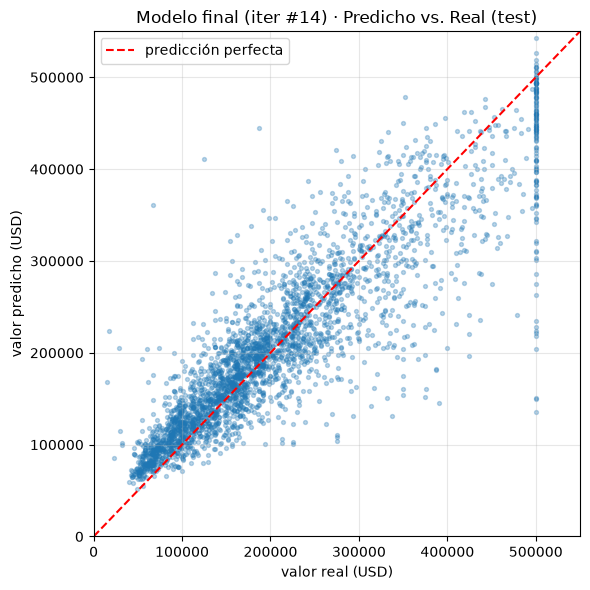

In [23]:
# Predicho vs. real sobre test (idealmente los puntos caen sobre la diagonal)
best["model"].eval()
with torch.no_grad():
    pred_test = scaler_y.inverse_transform(best["model"](X_test_t.to(device)).cpu().numpy()).ravel()
true_test = scaler_y.inverse_transform(y_test_t.numpy()).ravel()

plt.figure(figsize=(6, 6))
plt.scatter(true_test, pred_test, s=8, alpha=0.3)
lims = [0, 550_000]
plt.plot(lims, lims, "r--", lw=1.5, label="predicción perfecta")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("valor real (USD)"); plt.ylabel("valor predicho (USD)")
plt.title(f"Modelo final (iter #{best_id}) · Predicho vs. Real (test)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()